# Join inspections to parcels

To establish a clear unit of observation, we are joining inspection points to parcels for each year. When creating our defensible space buffer geometries, clip geometries to parcel boundaries, preventing overlap.

In [17]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("../utils")

import config

pd.set_option("display.max_columns", None)

## Import cleaned inspections data (2019-2023)

In [18]:
# Create a function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections

# Read in inspection data for 2019-2023 as separate dataframes
for year in range(2019, 2024):
    globals()[f'inspections_{year}'] = import_inspections_data(year)

### Drop `apn` variable from inspections data

Some of the inspections data appear to have assessor parcel numbers (APNs). However, because we will join the inspections data to parcel data obtained from Santa Barbara County, we will preserve the APNs associated with the parcel data instead.

In [19]:
# Find all columns with 'apn' in the name and check unique values for all inspection years
for year in range(2019, 2024):
    inspections = eval(f"inspections_{year}")
    apn_columns = inspections.columns[inspections.columns.str.contains("apn")]
    print(f"Year: {year}")
    print(f"{inspections[apn_columns].nunique()}\n")

Year: 2019
apn    0
dtype: int64

Year: 2020
apn    0
dtype: int64

Year: 2021
apn    103
dtype: int64

Year: 2022
apn    155
dtype: int64

Year: 2023
apn    154
dtype: int64



In [20]:
# Drop `apn_right` columns from inspection data for 2019-2023
for year in range(2019, 2024):
    globals()[f'inspections_{year}'] = inspections.drop(columns=["apn"])
    

In [21]:
# Confirm that `apn` columns have been dropped
for year in range(2019, 2024):
    inspections = eval(f"inspections_{year}")
    apn_columns = inspections.columns[inspections.columns.str.contains("apn")]
    print(f"Year: {year}")
    print(f"{inspections[apn_columns].nunique()}\n")

Year: 2019
Series([], dtype: float64)

Year: 2020
Series([], dtype: float64)

Year: 2021
Series([], dtype: float64)

Year: 2022
Series([], dtype: float64)

Year: 2023
Series([], dtype: float64)



## Import parcel data (2024)

In [22]:
parcels_2024 = os.path.join(
    config.data_dir,
    "Parcel_Maps_SpatialIndex_2024",
    "Parcel_Maps.shp",
)
parcels_2024 = gpd.read_file(parcels_2024)

## Import Parcel Data (2020)

In [23]:
# Read in complete parcels data and convert to Albers CRS
parcels = os.path.join(config.data_dir, "parcel_boundaries", "cbiinputs.gdb")
parcels = gpd.read_file(parcels).to_crs(config.albers_crs)

## Join inspections data to parcels for each year

In [24]:
def join_parcels_to_inspections(year):
    """
    Function to join inspections data to parcels data for a given year
    while preserving both geometries.
    """
    # Get the inspections GeoDataFrame for this year
    inspections_df = globals()[f'inspections_{year}']
    
    # Make a copy of the geometry columns with new names
    parcels_copy = parcels.copy()
    inspections_copy = inspections_df.copy()
    
    parcels_copy['parcel_geometry'] = parcels_copy.geometry
    inspections_copy['inspection_geometry'] = inspections_copy.geometry
    
    # Perform the spatial join
    joined = gpd.sjoin(parcels_copy, inspections_copy, how="inner", predicate="contains")
    
    # Rename columns for clarity
    joined = joined.rename(columns={'geometry': 'intersection_geometry', # intersection of parcel and inspection
                                   'parcel_geometry': 'geometry'})
    
    # Set the primary geometry to the parcel geometry
    joined = joined.set_geometry('geometry')
    
    return joined

# Join inspections data to parcels data for 2019-2023
for year in range(2019, 2024):
    globals()[f'joined_{year}'] = join_parcels_to_inspections(year)


In [25]:
# Check shape of inspections dataframes
inspections_2019.shape, inspections_2020.shape, inspections_2021.shape, inspections_2022.shape, inspections_2023.shape

((13373, 120), (13373, 120), (13373, 120), (13373, 120), (13373, 120))

In [26]:
# Check shape of joined dataframes
joined_2019.shape, joined_2020.shape, joined_2021.shape, joined_2022.shape, joined_2023.shape

((13544, 211), (13544, 211), (13544, 211), (13544, 211), (13544, 211))

## Plot parcel boundaries and inspections for each year

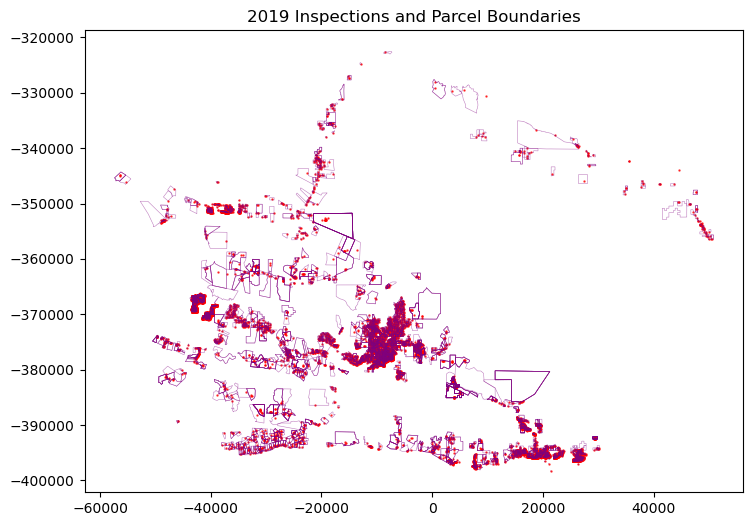

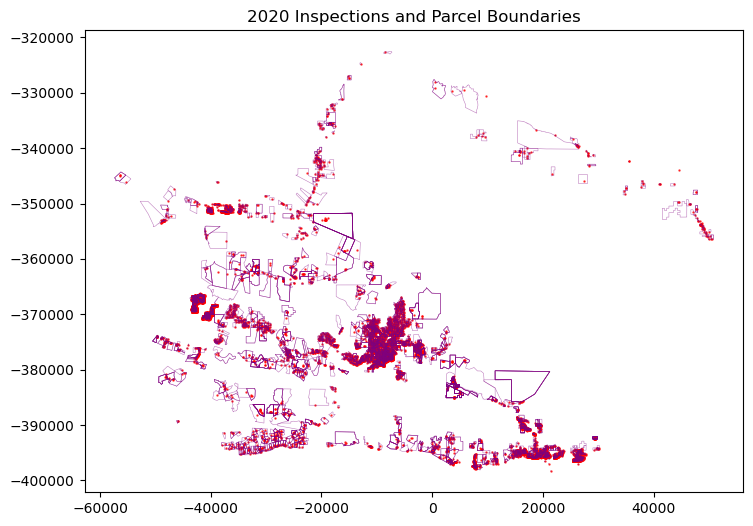

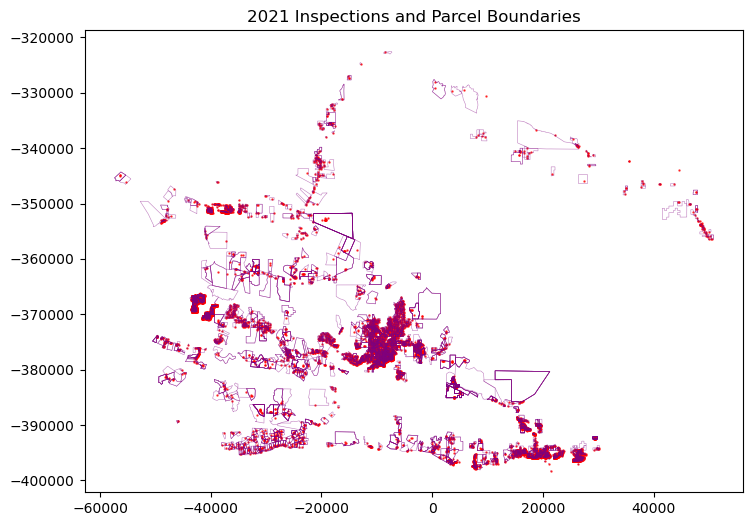

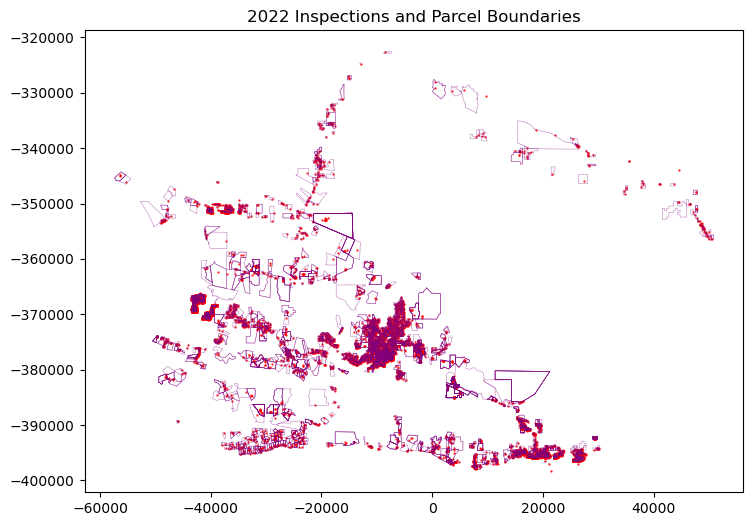

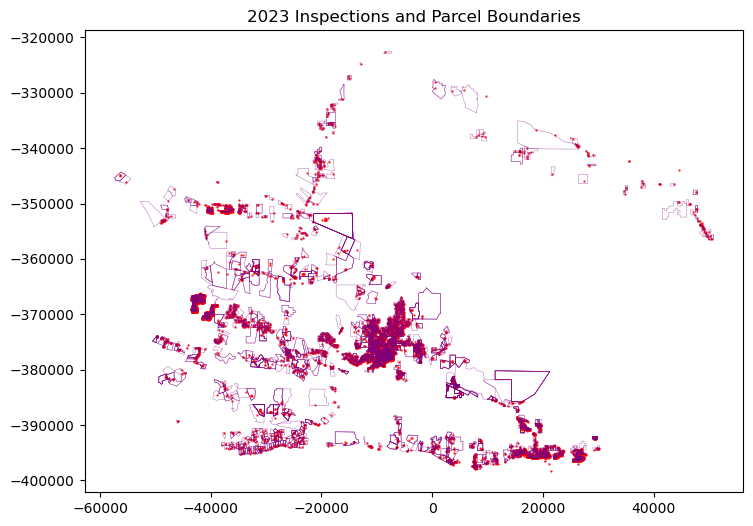

In [27]:
# Create a function that plots the joined data and inspections for each year
def plot_inspections(year):
    """
    Function to plot the joined data and inspections for a given year.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the joined data
    globals()[f"joined_{year}"].boundary.plot(
        ax=ax, color="purple", linewidth=0.4, alpha=0.5
    )

    # Plot the inspections data
    globals()[f"inspections_{year}"].plot(
        ax=ax, color="red", markersize=0.5, alpha=0.75
    )

    plt.title(f"{year} Inspections and Parcel Boundaries")
    plt.show()


# Plot inspections for each year
for year in range(2019, 2024):
    plot_inspections(year)

## Plot non-compliant inspection points

In [28]:
# Combine all years into a single DataFrame with a 'year' column
def create_combined_df(years):
    """
    Combines data from multiple years into a single DataFrame with a year column.
    """
    combined_parcels = []
    combined_inspections = []
    
    for year in years:
        # Get the joined parcels data and add year column
        parcels_df = globals()[f"joined_{year}"].copy()
        parcels_df['data_type'] = 'parcel'
        combined_parcels.append(parcels_df)
        
        # Get the inspections data and add year column
        insp_df = globals()[f"inspections_{year}"].copy()
        insp_df['year'] = year
        insp_df['data_type'] = 'inspection'
        # Filter for only Non-Compliant status
        insp_df = insp_df[insp_df['status'] == "Non-Compliant"]
        
        combined_inspections.append(insp_df)
    
    # Combine all years
    all_parcels = pd.concat(combined_parcels)
    all_inspections = pd.concat(combined_inspections)
    
    return all_parcels, all_inspections

# Create a function to plot using seaborn FacetGrid
def plot_with_facetgrid(years):
    """
    Plot inspections and parcels using seaborn FacetGrid.
    """
    all_parcels, all_inspections = create_combined_df(years)
    
    # Create FacetGrid for parcels
    g = sns.FacetGrid(all_parcels, col='year', col_wrap=3, height=5, sharex=False, sharey=False)
    
    # Define a mapping function that plots both parcels and inspections
    def plot_both(data, **kwargs):
        year = data['year'].iloc[0]
        # Plot parcels
        ax = plt.gca()
        data.boundary.plot(ax=ax, color="purple", linewidth=0.3, alpha=0.2)
        # Plot inspections for this year
        insp = all_inspections[all_inspections['year'] == year]
        insp.plot(ax=ax, color="red", markersize=2)
        ax.set_axis_off()
    
    # Apply the mapping function
    g.map_dataframe(plot_both)
    
    g.set_titles("{col_name}")
    plt.suptitle("Non-Compliant Inspections and Parcel Boundaries by Year", fontsize=16, y=1.02)
    plt.show()

# Plot using FacetGrid
plot_with_facetgrid(range(2019, 2024))

KeyError: 'year'

## Plot non-compliant points with roads

In [ ]:
# Import sb county roads
roads = os.path.join(
    config.data_dir, "sb_roads_2023", "tl_2023_06083_roads", "tl_2023_06083_roads.shp"
)
roads = gpd.read_file(roads).to_crs(config.albers_crs)

# Remove roads where the longitude is less than -420000 to exclude the Channel Islands
roads = roads[roads.geometry.centroid.y > -420000]

# Plot roads
roads.plot()

In [ ]:
# Combine all years into a single DataFrame with a 'year' column
def create_combined_df(years):
    """
    Combines data from multiple years into a single DataFrame with a year column.
    """
    combined_parcels = []
    combined_inspections = []
    
    for year in years:
        # Get the joined parcels data and add year column
        parcels_df = globals()[f"joined_{year}"].copy()
        parcels_df['year'] = year
        parcels_df['data_type'] = 'parcel'
        combined_parcels.append(parcels_df)
        
        # Get the inspections data and add year column
        insp_df = globals()[f"inspections_{year}"].copy()
        insp_df['year'] = year
        insp_df['data_type'] = 'inspection'
        # Filter for only Non-Compliant status
        insp_df = insp_df[insp_df['status'] == "Non-Compliant"]
        
        combined_inspections.append(insp_df)
    
    # Combine all years
    all_parcels = pd.concat(combined_parcels)
    all_inspections = pd.concat(combined_inspections)
    
    return all_parcels, all_inspections

# Create a function to plot using seaborn FacetGrid
def plot_with_facetgrid(years):
    """
    Plot inspections and parcels using seaborn FacetGrid.
    """
    all_parcels, all_inspections = create_combined_df(years)
    
    # Create FacetGrid for parcels
    g = sns.FacetGrid(all_parcels, col='year', col_wrap=3, height=5, sharex=False, sharey=False)
    
    # Define a mapping function that plots both parcels and inspections
    def plot_both(data, **kwargs):
        year = data['year'].iloc[0]
        # Plot parcels
        ax = plt.gca()
        roads.plot(ax=ax, color="purple", linewidth=0.3, alpha=0.2)
        # Plot inspections for this year
        insp = all_inspections[all_inspections['year'] == year]
        insp.plot(ax=ax, color="red", markersize=2)
        ax.set_axis_off()
    
    # Apply the mapping function
    g.map_dataframe(plot_both)
    
    # Add titles
    g.set_titles("{col_name}")
    plt.suptitle("Non-Compliant Inspections by Year", fontsize=16, y=1.02)
    plt.show()

# Plot using FacetGrid
plot_with_facetgrid(range(2019, 2024))

## Plot non-compliant points with a basemap

In [ ]:
import contextily as ctx
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a function to plot using seaborn FacetGrid with basemap
def plot_with_facetgrid_basemap(years):
    """
    Plot inspections and parcels using seaborn FacetGrid with a basemap.
    """
    all_parcels, all_inspections = create_combined_df(years)
    
    # Create FacetGrid for parcels
    g = sns.FacetGrid(all_parcels, col='year', col_wrap=3, height=5, sharex=False, sharey=False)
    
    # Define a mapping function that plots both parcels and inspections with basemap
    def plot_both(data, **kwargs):
        year = data['year'].iloc[0]
        ax = plt.gca()
        
        # Ensure data is in the correct CRS for web map tiles (EPSG:3857)
        parcels_3857 = data.to_crs(epsg=3857)
        
        # Plot inspections for this year
        insp = all_inspections[all_inspections['year'] == year]
        insp_3857 = insp.to_crs(epsg=3857)
        insp_3857.plot(ax=ax, color="red", markersize=2)
        
        # Add basemap
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        
        # Set title for this subplot
        ax.set_title(f"Year: {year}")
        
        # Remove axis
        ax.axis('off')
    
    # Apply the mapping function
    g.map_dataframe(plot_both)
    
    # Add overall title
    plt.suptitle("Non-Compliant Inspections by Year", fontsize=16, y=1.02)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Plot using FacetGrid with basemap
plot_with_facetgrid_basemap(range(2019, 2024))